In [1]:
# Operações Numéricas
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Redes Neurais
import tensorflow as tf

# Redes Neurais - Alto Nível
from tensorflow import keras

# Importando as camadas de rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

# Bibliotecas de Imagem
from tensorflow.keras.utils import load_img, img_to_array

# Carregar base CIFAR-10

In [ ]:
# Carregar base CIFAR

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar valores para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'avião',
    'automóvel',
    'pássaro',
    'gato',
    'cervo',
    'cachorro',
    'sapo',
    'cavalo',
    'navio',
    'caminhão'
]

print(f"Formato de x_train: ", x_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de x_test: ", x_test.shape)
print(f"Formato de y_test: ", y_test.shape)

Formato de x_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de x_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


# Plotar Algumas Imagens

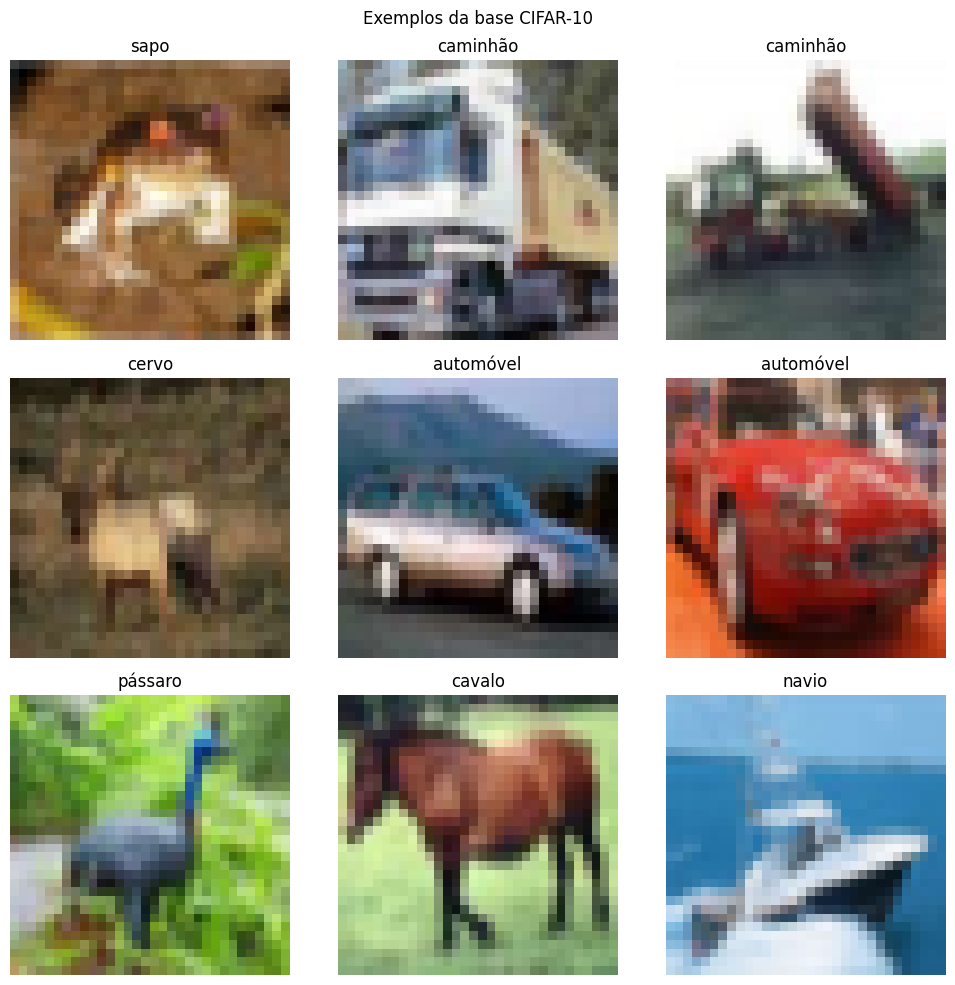

In [5]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)                # divide o plot em 3 linhas e 3 colunas
    plt.imshow(x_train[i])                  # carrega a imagem na posição i
    plt.title(class_names[y_train[i]])      # pega o nome da classe referente
    plt.axis('off')                         # remove os eixos
plt.suptitle("Exemplos da base CIFAR-10")   # define o subtítulo do gráfico
plt.tight_layout()                          # remove espaços não usados
plt.show()                                  # exibe a imagem

# Criação do Modelo CNN

In [ ]:
model = keras.Sequential()

# Camada de Entrada
model.add(Input(shape=(32, 32, 3)))                                     # Definindo o formato de entrada dos dados

# Definindo os Blocos - Convolução x Pooling

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))    # Definindo a camada de convolução com 16 filtros de tamanho 3 x 3
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))    # Definindo a camada de convolução com 32 filtros de tamanho 3 x 3 
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))    # Definindo a camada de convolução com 64 filtros de tamanho 3 x 3 
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN -> Dense  (Totalmente conectado)
model.add(Flatten())                                                    
model.add(Dense(units=64, activation='relu'))                           
model.add(Dense(units=len(class_names), activation='softmax'))

# Compilação do Modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo do Modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

# Treinar a Rede

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7017 - loss: 0.8494 - val_accuracy: 0.6481 - val_loss: 1.0500
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7129 - loss: 0.8228 - val_accuracy: 0.6810 - val_loss: 0.9470
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7198 - loss: 0.8000 - val_accuracy: 0.6782 - val_loss: 0.9510
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7256 - loss: 0.7797 - val_accuracy: 0.6749 - val_loss: 0.9682
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7353 - loss: 0.7558 - val_accuracy: 0.6792 - val_loss: 0.9493
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7430 - loss: 0.7353 - val_accuracy: 0.6732 - val_loss: 0.9766
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7469 - loss: 0.7191 - val_accuracy: 0.6853 - val_loss: 0.9426
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7557 - loss: 0.6939 - val_accuracy: 0.

# Plot da Acurácia e do Loss

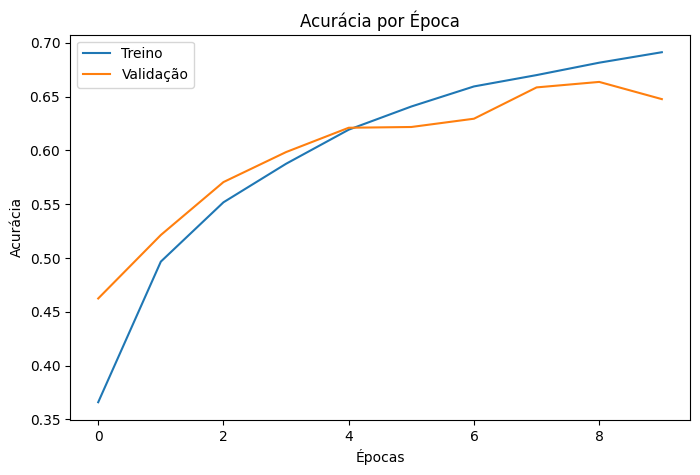

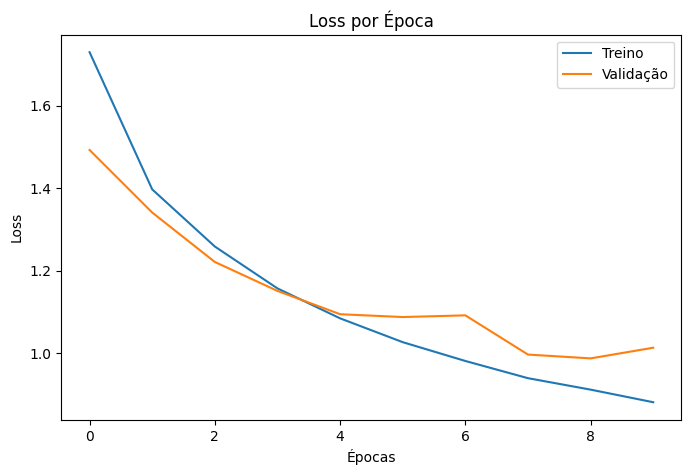

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Treino")           # Acurácia no treino
plt.plot(history.history['val_accuracy'], label="Validação")    # Acurácia na validação
plt.title("Acurácia por Época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label="Treino")           # Acurácia no treino
plt.plot(history.history['val_loss'], label="Validação")    # Acurácia na validação
plt.title("Loss por Época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()